# 2D Wave-equation / linearized shallow-water equation on a rectangular domain

The two-dimensional shallow-water equations can be linearized and simplified to the 2D wave-equation:

$\partial h/\partial t + D \partial u / \partial x + D \partial u / \partial y = 0$

$\partial u/\partial t + g \partial h / \partial x = 0$

$\partial v/\partial t + g \partial h / \partial y = 0$

where $h$ denotes the water-height above the reference, $u$ and $v$ the velocity in x and y-directions, $D$ the depth below the reference and $t,x,y$ time and space.

In [1]:
using Pkg 
Pkg.activate("..")  # activate the environment WITH GPU for this notebook
using CUDA
using DifferentialEquations
using ComponentArrays
using Plots
using LinearAlgebra
using SparseArrays
using BenchmarkTools

  Activating project at `~/src_nobackup/CeleriTide.jl`


In [2]:
# Here we use sparse arrays for implementing the spatial derivatives
# For use on GPU these sparse matrices can be converted to CUDA Sparse matrices.
"""
    Compute the spatial derivative first order to right
    function ∂x_right_matrix
    return sparse matrix. Push to GPU explicitly for use with CUDA
"""
function ∂x_right_matrix(nx,Δx)
    row_indices=Int64[]
    col_indices=Int64[]
    values=Float64[]
    @inbounds for i in 1:(nx-1)
        push!(row_indices,i)
        push!(col_indices,i)
        push!(values,-1.0/Δx)
        push!(row_indices,i)
        push!(col_indices,i+1)
        push!(values,1.0/Δx)
    end
    push!(row_indices,nx)
    push!(col_indices,nx)
    push!(values,-1.0/Δx)
    return sparse(row_indices,col_indices,values,nx,nx)
end

"""
Compute the spatial derivative first order to left
function ∂x_left_matrix
return sparse matrix. Push to GPU explicitly for use with CUDA
"""
function ∂x_left_matrix(nx,Δx)
    row_indices=Int64[]
    col_indices=Int64[]
    values=Float64[]
    @inbounds for i in 2:nx
        push!(row_indices,i)
        push!(col_indices,i)
        push!(values,1.0/Δx)
        push!(row_indices,i)
        push!(col_indices,i-1)
        push!(values,-1.0/Δx)
    end
    push!(row_indices,1)
    push!(col_indices,1)
    push!(values,1.0/Δx)
    return sparse(row_indices,col_indices,values,nx,nx)
end

"""
    Compute the spatial derivative first order to right
    function ∂y_right_matrix return sparse matrix. 
    Push to GPU explicitly for use with CUDA
"""
function ∂y_right_matrix(ny,Δy)
    row_indices=Int64[]
    col_indices=Int64[]
    values=Float64[]
    @inbounds for i in 1:(ny-1)
        push!(col_indices,i)
        push!(row_indices,i)
        push!(values,-1.0/Δy)
        push!(col_indices,i)
        push!(row_indices,i+1)
        push!(values,1.0/Δy)
    end
    push!(col_indices,ny)
    push!(row_indices,ny)
    push!(values,-1.0/Δy)
    return sparse(row_indices,col_indices,values,ny,ny)
end

"""
Compute the spatial derivative first order to left
function ∂y_left_matrix return sparse matrix. 
Push to GPU explicitly for use with CUDA
"""
function ∂y_left_matrix(ny,Δy)
    row_indices=Int64[]
    col_indices=Int64[]
    values=Float64[]
    @inbounds for i in 2:ny
        push!(col_indices,i)
        push!(row_indices,i)
        push!(values,1.0/Δy)
        push!(col_indices,i)
        push!(row_indices,i-1)
        push!(values,-1.0/Δy)
    end
    push!(col_indices,1)
    push!(row_indices,1)
    push!(values,1.0/Δy)
    return sparse(row_indices,col_indices,values,ny,ny)
end


∂y_left_matrix

In [3]:
"""
    Wave2D
    container for the parameters of the 2D wave equation
    We use a 'functor', i.e. a struct that behaves like a function.
    So this function can contain data, eg parameters.
"""
struct Wave2D{T}
    g::T # gravity
    D::T # depth
    Lx::T # length
    Ly::T # length
    Δx::T # spatial step
    Δy::T # spatial step
    nx::Int64 # number of spatial points
    ny::Int64 # number of spatial points
    ∂h∂x::AbstractMatrix{T} # cache arrays
    ∂h∂y::AbstractMatrix{T} 
    ∂u∂x::AbstractMatrix{T}
    ∂v∂y::AbstractMatrix{T}
    Dx_h::AbstractMatrix{T} # x derivative matrix for h
    Dy_h::AbstractMatrix{T}
    Dx_u::AbstractMatrix{T}
    Dy_v::AbstractMatrix{T}
end

"""
    Wave2D
    Compute time derivative of the state
    function (f::Wave2D)(dx_dt,x,p,t)
    This is a functor, so it's based on the Wave2D struct, and can access its data
"""
function (f::Wave2D)(dx_dt,x,p,t)
    g=f.g
    D=f.D
    # temporary variables
    ∂h∂x = f.∂h∂x
    ∂h∂y = f.∂h∂y
    ∂u∂x = f.∂u∂x
    ∂v∂y = f.∂v∂y
    Dx_h = f.Dx_h
    Dy_h = f.Dy_h
    Dx_u = f.Dx_u
    Dy_v = f.Dy_v
    # compute spatial derivatives
    mul!(∂h∂x,Dx_h,x.h)
    mul!(∂h∂y,x.h,Dy_h)
    mul!(∂u∂x,Dx_u,x.u)
    mul!(∂v∂y,x.v,Dy_v)
    # compute time derivatives
    ## Continuity
    @. dx_dt.h = -D * (∂u∂x + ∂v∂y)
    ## Momentum x and y
    @. dx_dt.u = -g * ∂h∂x
    @. dx_dt.v = -g * ∂h∂y
end


Wave2D

In [4]:
# Staggered grid and initial condition
function h_grid(nx,ny,Δx,Δy)
    return (Δx*(0.0:1:(nx-1)),Δy*(0:1:(ny-1)))
end

function u_grid(nx,ny,Δx,Δy)
    return (0.5*Δx.+Δx*(0.0:1:(nx-1)),Δy*(0:1:(ny-1)))
end

function v_grid(nx,ny,Δx,Δy)
    return (Δx*(0.0:1:(nx-1)),0.5*Δy.+Δy*(0:1:(ny-1)))
end

function gaussian_bump(xs,ys,height,x_center,y_center,x_width,y_width)
    return [height*exp(-((x-x_center)^2/(2*x_width^2))
      -((y-y_center)^2/(2*y_width^2))) for x in xs, y in ys]
end

nothing

In [31]:
#parameters
nx=200     # number of spatial points
ny=200     # number of spatial points
Lx=10000.0  # length
Ly=10000.0  # length
Δx=Lx/nx    # spatial step for x
Δy=Ly/ny    # spatial step for y
D=10.0     # depth
g=10.0     # gravity
time_span=(0.0,1000.0) # time span
const run_on_cuda = false

false

In [32]:
#initialization

# spatial grid
(x_h,y_h)=h_grid(nx,ny,Δx,Δy)
(x_u,y_u)=u_grid(nx,ny,Δx,Δy)
(x_v,y_v)=v_grid(nx,ny,Δx,Δy)

# spatial derivatives on Arakawa C-grid
Dx_h_ =∂x_right_matrix(nx,Δx)
Dy_h_ =∂y_right_matrix(ny,Δy)
Dx_u_ =∂x_left_matrix(nx,Δx)
Dy_v_ =∂y_left_matrix(ny,Δy)

# initial condition
h0_=gaussian_bump(x_h,y_h,1.0,0.5*Lx,0.5*Ly,0.1*Lx,0.1*Ly)
u0_=zeros(nx,ny)
v0_=zeros(nx,ny)

# -- push to GPU if needed
if run_on_cuda
    T=Float32
    Dx_h=CUDA.CUSPARSE.CuSparseMatrixCSC{T}(Dx_h_) # push to GPU as sparse matrix
    Dy_h=CUDA.CUSPARSE.CuSparseMatrixCSC{T}(Dy_h_)
    Dx_u=CUDA.CUSPARSE.CuSparseMatrixCSC{T}(Dx_u_)
    Dy_v=CUDA.CUSPARSE.CuSparseMatrixCSC{T}(Dy_v_)
    #Dx_h=CuArray{T}(Dx_h) # push as full matrix ... not needed
    h0=CuArray{T}(h0_) # push to GPU
    u0=CuArray{T}(u0_)
    v0=CuArray{T}(v0_)
else
    T=Float64
    Dx_h=Dx_h_
    Dy_h=Dy_h_
    Dx_u=Dx_u_
    Dy_v=Dy_v_
    h0=h0_
    u0=u0_
    v0=v0_
end

x0=ComponentVector(h=h0,u=u0,v=v0) # initial condition

# allocate memory for temporal storage of the spatial derivatives 
∂h∂x=similar(h0)
∂h∂y=similar(h0)
∂u∂x=similar(u0)
∂v∂y=similar(v0) 

# functor for the 2D wave equation
f=Wave2D{T}(g,D,Lx,Ly,Δx,Δy,nx,ny,∂h∂x,∂h∂y,∂u∂x,∂v∂y,Dx_h,Dy_h,Dx_u,Dy_v)


Wave2D{Float64}(10.0, 10.0, 10000.0, 10000.0, 50.0, 50.0, 200, 200, [0.0 0.0 … 0.0 0.0; 2.018006e-318 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [6.53183321749713e-310 6.53178092048963e-310 … 6.5318340401607e-310 6.53183239635607e-310; 2.20749e-318 6.53195705891683e-310 … 6.53195697829164e-310 6.53195697829164e-310; … ; 6.5317809204841e-310 6.5318332246615e-310 … 6.531834040469e-310 6.53183405696526e-310; 6.53195705891683e-310 6.53195697829164e-310 … 6.53195697829164e-310 6.53195697829164e-310], [6.53216212821246e-310 6.531837029997e-310 … 6.53183038854523e-310 6.53183038884404e-310; 2.683282617e-315 6.53195705891683e-310 … 6.53195697829164e-310 6.53195697829164e-310; … ; 6.53183702999145e-310 6.5318296811096e-310 … 6.5318303888322e-310 6.5318303996787e-310; 6.53195705891683e-310 6.53195697829164e-310 … 6.53195697829164e-310 6.53195697829164e-310], [6.5318303997285e-310 6.5318333966335e-310 … 6.53183136425215e-310 6.53183817484273e-310; 6.53195697829164e-310 6.5319570589

In [33]:
# # test f
# # @show f
# dx_dt=similar(x0) # temporary storage for the time derivative
# f(dx_dt,x0,(),0.0) # test the functor
# #@show f.∂h∂x

# nothing

In [34]:
# setup the ODE problem
wave_ode=ODEProblem(f,x0,time_span)
# solve the ODE problem
# select no output for benchmarking
@time sol_no_ouput=solve(wave_ode, Tsit5(),save_everystep=false,save_start=false,save_end=false); #first time includes compilation time
@time sol_no_ouput=solve(wave_ode, Tsit5(),save_everystep=false,save_start=false,save_end=false); # do not save the solution when benchmarking
@time sol=solve(wave_ode, Tsit5()); # now save the solution
#CUDA.@time sol=solve(wave_ode, Tsit5()); # now save the solution
#CUDA.@time sol=solve(wave_ode, Tsit5(),save_everystep=false,save_start=false,save_end=true); # now save the solution

  2.643840 seconds (6.51 M allocations: 446.120 MiB, 4.57% gc time, 70.52% compilation time)
  0.788131 seconds (31.92 k allocations: 15.807 MiB, 3.32% gc time)
  3.574955 seconds (2.98 M allocations: 2.284 GiB, 39.01% gc time, 21.28% compilation time)


retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 291-element Vector{Float64}:
    0.0
    0.09954299631565747
    1.0949729594722322
    5.661335428376644
   12.853811387231612
   20.994649908558852
   30.940895469906863
   41.67134529333124
   52.68614730201187
   62.98055996063081
    ⋮
  980.8272489349241
  983.3262308118561
  985.7691032713179
  988.2564780691634
  990.6732182142415
  993.1653543392354
  995.5684599633323
  998.0357386147214
 1000.0
u: 291-element Vector{ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(h = ViewAxis(1:40000, ShapedAxis((200, 200))), u = ViewAxis(40001:80000, ShapedAxis((200, 200))), v = ViewAxis(80001:120000, ShapedAxis((200, 200))))}}}}:
 ComponentVector{Float64}(h = [1.3887943864964021e-11 1.781019624282766e-11 … 2.2783147454596494e-11 1.781019624282766e-11; 1.781019624282766e-11 2.2840176579937026e-11 … 2.921759557361908e-11 2.2840176579937026e-11; … ; 2.2783147454596494e-11 2.921759557361908e-11 … 3.737571327944

┌ Info: Saved animation to /tmp/jl_g1uBWDApqh.gif
└ @ Plots /home/verlaan/.julia/packages/Plots/du2dt/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_g1uBWDApqh.gif")
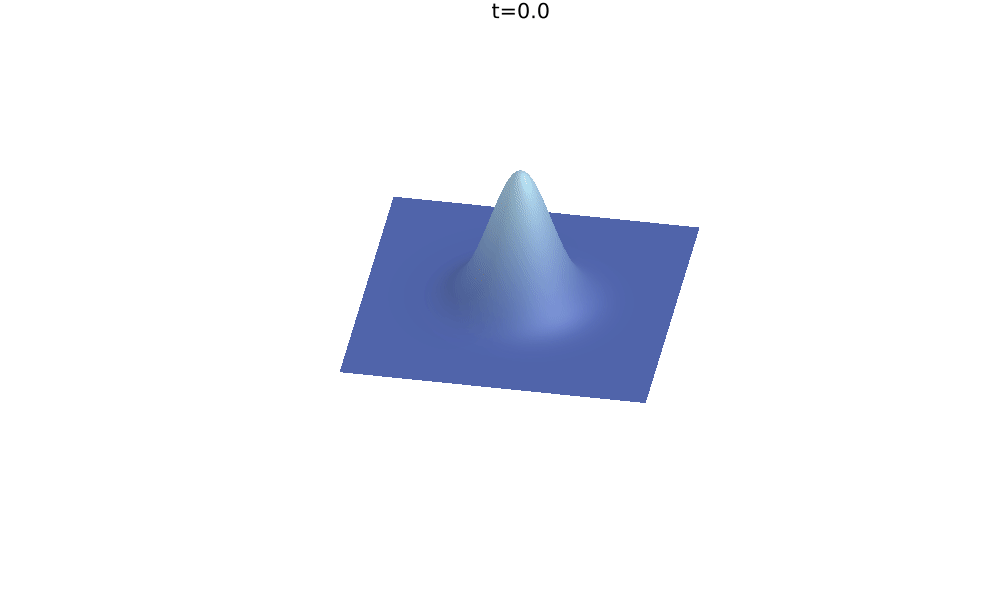

In [36]:
"""
function plot_wave1d(f,sol,t)
Create a plot from the 1d wave equation solution at time t
"""
function plot_wave2d(f,sol,t)
    nx=f.nx
    ny=f.ny
    Δx=f.Δx
    Δy=f.Δy
    (x_h,y_h)=h_grid(nx,ny,Δx,Δy)
    surface(x_h,y_h,Array(sol(t).h),c=cgrad(:blues,rev=true),
    zlims=[-1.0,1.0],label="t=$(t)",xlims=(0.0,f.Lx),ylims=(0.0,f.Ly),clims=(-1.0,1.0),camera = (10, 35),
                     cbar=false,axis=false,grid=false,size=(1000,600)) #clims=(-0.5,0.5),
    title!("t=$(t)")
end
   
function animate_wave2d(f,sol, timestep=10.0, fps=30)
	# create an animation
    times = sol.t[1]:timestep:sol.t[end] # times at which to plot
    ntimes = length(times)
    ani
    m = @animate for i in 1:ntimes
      plot_wave2d(f,sol,times[i])
    end
	return gif(anim, fps = fps)
end

animate_wave2d(f,sol,10.0, 10)